# Keyword analysis

In [1]:
# import sys
#
# if ".." not in sys.path:
#     sys.path.append("..")

import html

import great_tables as gt
#import numpy as np
import polars as pl
#from scipy.stats import chi2_contingency, fisher_exact

import polars_corpus as plc
import matplotlib.pyplot as plt
import seaborn as sns

from polars_corpus.utils import (
    as_corpus,
    as_expr,
    check_expr,
)


In [2]:
bnc = pl.scan_parquet("bnc.parquet").set_sorted("file_id")
speakers = pl.scan_parquet("bnc-speakers.parquet")

speakers = speakers.filter(pl.col("sex").is_in(["m", "f"]))
speakers.group_by("sex").len()

bnc = (
    bnc.filter(pl.col("text_type") == "CONVRSN")
    .join(speakers, on="speaker_id", how="inner")
    .with_columns(pl.col("token").str.to_lowercase().alias("norm"))
)

Stefanowitsch (2020), pp. 378–380

In [3]:
male_keywords = plc.keywords(
    target = bnc.filter(pl.col('sex')=='m'),
    reference= bnc.filter(pl.col('sex')=='f'),
    method='ll',
    expr=pl.col('token').str.to_lowercase()
).collect(engine="streaming")

In [4]:
male_keywords

token,freqs,target_df,LogLik
str,struct[4],u32,f64
"""fucking""","{1383,1709,1784723,4530265}",47,1237.920581
"""er""","{9415,18752,1784723,4530265}",130,900.794048
"""the""","{43385,100752,1784723,4530265}",134,574.376875
""",""","{84406,203556,1784723,4530265}",133,380.46747
"""yeah""","{21888,50681,1784723,4530265}",131,305.64689
…,…,…,…
"""i""","{54825,148155,1784723,4530265}",135,-369.237042
"""n't""","{24221,68601,1784723,4530265}",136,-494.184219
"""said""","{4911,17286,1784723,4530265}",127,-915.450508


In [5]:
female_keywords = plc.keywords(
    target = bnc.filter(pl.col('sex')=='f'),
    reference= bnc.filter(pl.col('sex')=='m'),
    method='ll',
    expr=pl.col('token').str.to_lowercase()
).collect(engine="streaming")

<Axes: xlabel='LogLik'>

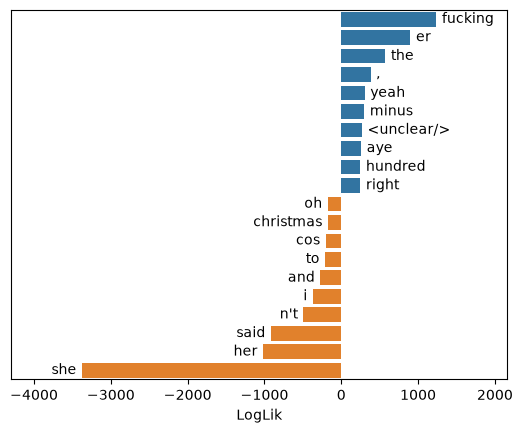

In [6]:
# def keyword_plot(keyword_df, expr, keyness, top_k=10, bottom_k=10):

#     term = as_expr(expr)
#     lf = as_corpus(keyword_df)
#     term_name = check_expr(lf, term)
#     keyness_name = check_expr(lf, keyness)

#     top_items = lf.head(top_k).collect()       
#     ax = sns.barplot(x=keyness_name, 
#                      y=term_name, 
#                      data=top_items, 
#                      orient='h')
#     ax.bar_label(ax.containers[0], 
#                  labels=top_items[term_name], 
#                  padding=4)


#     bottom_items = lf.tail(bottom_k).collect()       
#     sns.barplot(x=keyness_name, 
#                      y=term_name, 
#                      data=bottom_items, 
#                      orient='h',
#                ax=ax)
#     ax.bar_label(ax.containers[1], 
#                  labels=bottom_items[term_name], 
#                  padding=4)

#     ax.set_yticks([])
#     ax.set_ylabel("")
#     ax.margins(x=0.2)

    
        
#     return ax
    
#     # ax.bar_label(ax.containers[0], labels=male_keywords.head(10)['token'], padding=4)

# # sns.barplot(y='token', x='LogLik', data=male_keywords.tail(10), orient='h', ax=ax)
# # ax.bar_label(ax.containers[1], labels=male_keywords.tail(10)['token'], padding=4)

plc.keyword_plot(male_keywords, 'token', 'LogLik')
# ax

In [13]:
tbl = (
    male_keywords.head(20)
    .select("token",
            pl.col('freqs').struct.field('f12').alias('male_freq'),
            (pl.col('freqs').struct.field('f1')-pl.col('freqs').struct.field('f12')).alias('female_freq'),
            'LogLik')
    .style.fmt_number(["LogLik"], decimals=2)
    .fmt_integer(["male_freq", "female_freq"], use_seps=True)
    .fmt(html.escape, columns=["token"])
    .cols_label(
        {
            "token": "word",
            "LogLik": "LL",
            "male_freq": "m freq",
            "female_freq": "f freq",
        }
    )
    .opt_row_striping()
    .opt_vertical_padding(0.6)
)

#tbl.save("LL")
tbl

ModuleNotFoundError: great_tables is required for `.style`

In [40]:
tbl = (
    female_keywords.head(20)
    .select("token",
            pl.col('freqs').struct.field('f12').alias('male_freq'),
            (pl.col('freqs').struct.field('f1')-pl.col('freqs').struct.field('f12')).alias('female_freq'),
            'LogLik')
    .style.fmt_number(["LogLik"], decimals=2)
    .fmt_integer(["male_freq", "female_freq"], use_seps=True)
    .fmt(html.escape, columns=["token"])
    .cols_label(
        {
            "token": "word",
            "LogLik": "LL",
            "male_freq": "m freq",
            "female_freq": "f freq",
        }
    )
    .opt_row_striping()
    .opt_vertical_padding(0.6)
)

#tbl.save("LL")
tbl

word,m freq,f freq,LL
she,"22,807","7,037","3,373.99"
her,"7,306","2,313","1,017.04"
said,"12,375","4,911",915.45
n't,"44,380","24,221",494.18
i,"93,330","54,825",369.24
and,"50,467","29,109",271.30
to,"40,934","23,693",207.09
cos,"6,864","3,314",204.47
christmas,"1,005",285,175.17
oh,"23,472","13,236",174.57


Lijffijt et al. (2016)

In [42]:
male_keywords = plc.keywords(
    target = bnc.filter(pl.col('sex')=='m'),
    reference= bnc.filter(pl.col('sex')=='f'),
    method='ttest',
    expr=pl.col('token').str.to_lowercase()
).collect(engine="streaming")

In [43]:
female_keywords = plc.keywords(
    target = bnc.filter(pl.col('sex')=='f').lazy(),
    reference= bnc.filter(pl.col('sex')=='m'),
    method='ttest',
    expr=pl.col('token').str.to_lowercase()
).collect(engine="streaming")